Using Colab cache for faster access to the 'world-happiness-2015-2024' dataset.
Dataset downloaded successfully!
Dataset Path:
/kaggle/input/world-happiness-2015-2024

CSV Files Found:
/kaggle/input/world-happiness-2015-2024/world_happiness_2018.csv
/kaggle/input/world-happiness-2015-2024/world_happiness_2023.csv
/kaggle/input/world-happiness-2015-2024/world_happiness_2022.csv
/kaggle/input/world-happiness-2015-2024/world_happiness_2016.csv
/kaggle/input/world-happiness-2015-2024/world_happiness_2015.csv
/kaggle/input/world-happiness-2015-2024/world_happiness_2017.csv
/kaggle/input/world-happiness-2015-2024/world_happiness_2019.csv
/kaggle/input/world-happiness-2015-2024/world_happiness_2020.csv
/kaggle/input/world-happiness-2015-2024/world_happiness_2021.csv
/kaggle/input/world-happiness-2015-2024/world_happiness_2024.csv
/kaggle/input/world-happiness-2015-2024/world_happiness_combined.csv

Using CSV File:
/kaggle/input/world-happiness-2015-2024/world_happiness_combined.csv

Dataset L

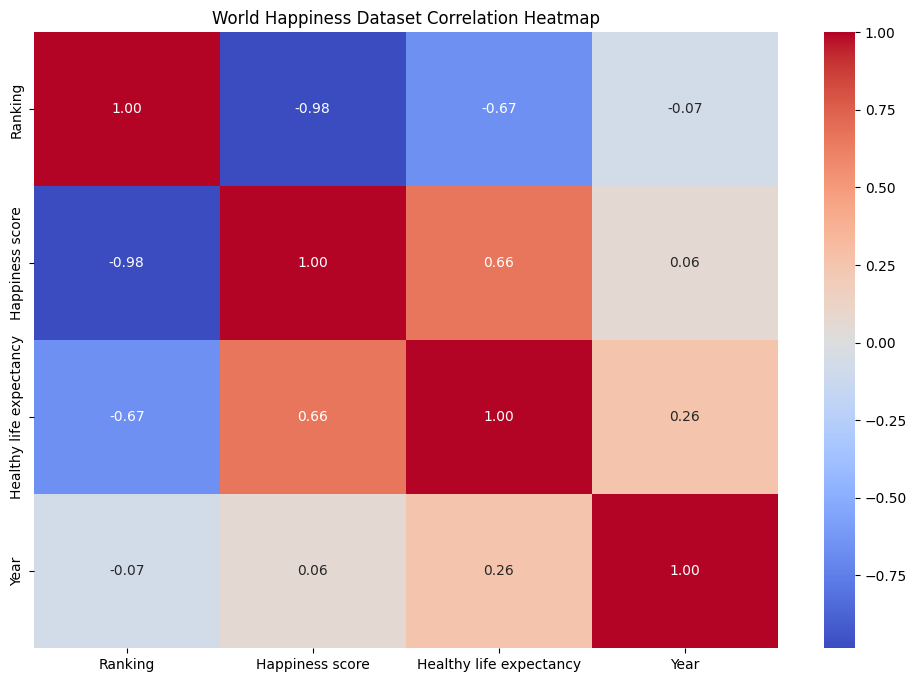

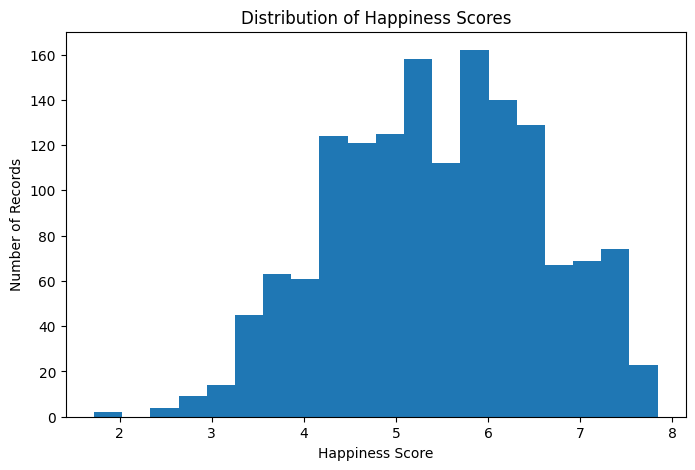

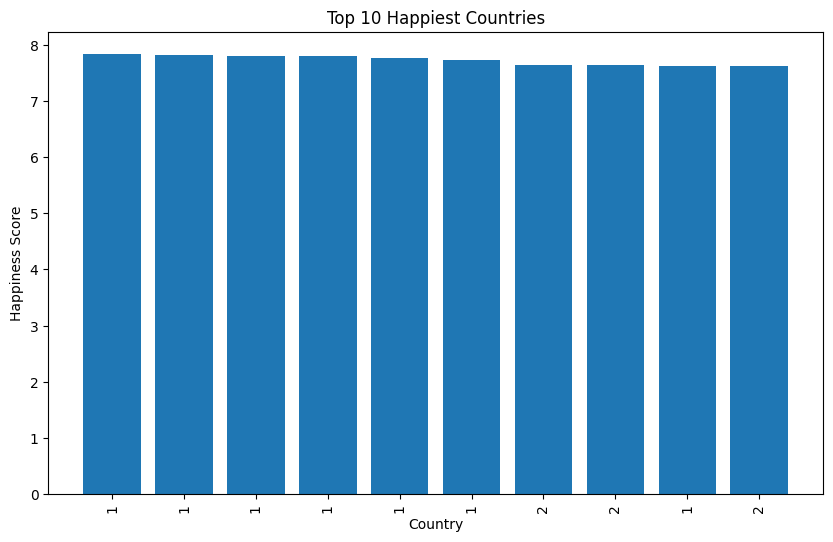


Numerical Columns:
['Ranking', 'Happiness score', 'Healthy life expectancy', 'Year']


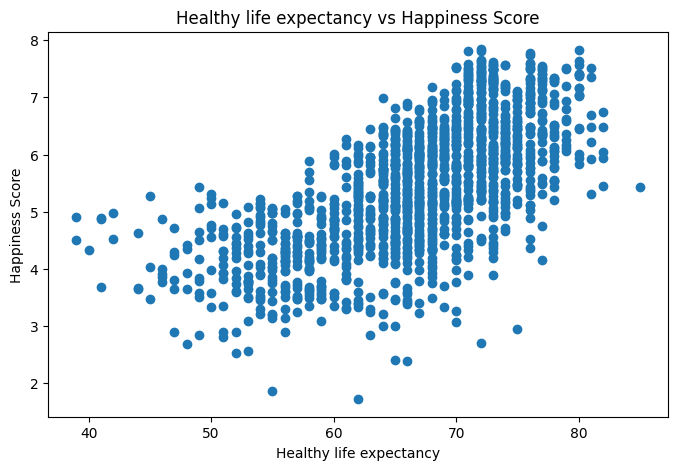


Year-wise Average Happiness
   Year  Happiness score
0  2015         5.375734
1  2016         5.382185
2  2017         5.354019
3  2018         5.372920
4  2019         5.405077
5  2020         5.472830
6  2021         5.532814
7  2022         5.554175
8  2023         5.539755
9  2024         5.530882


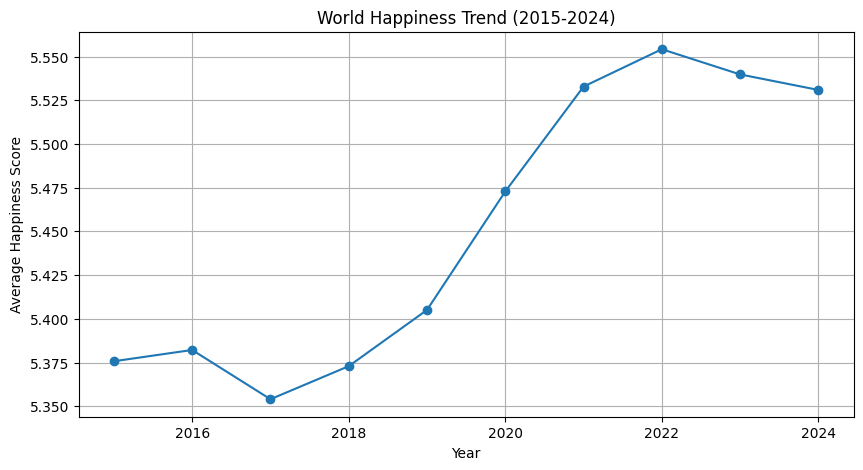


CSV, Excel and JSON files exported successfully.

WORLD HAPPINESS ANALYSIS COMPLETED
Dataset Shape: (1502, 11)
Total Records: 1502
Total Missing Values: 3
Average Happiness Score: 5.448857190412783
Maximum Happiness Score: 7.8421
Minimum Happiness Score: 1.721


In [8]:
# ============================================================
# WORLD HAPPINESS DATA ANALYSIS
# 2015 - 2024
# ============================================================

# Install KaggleHub
!pip -q install kagglehub

# ============================================================
# PROGRAM 1 - IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

# ============================================================
# PROGRAM 2 - FETCH DATASET DIRECTLY FROM KAGGLE
# ============================================================

import kagglehub

path = kagglehub.dataset_download(
    "yadiraespinoza/world-happiness-2015-2024"
)

print("Dataset downloaded successfully!")
print("Dataset Path:")
print(path)

# ============================================================
# PROGRAM 3 - FIND CSV FILE
# ============================================================

csv_files = glob.glob(
    os.path.join(path, "**", "*.csv"),
    recursive=True
)

print("\nCSV Files Found:")

for file in csv_files:
    print(file)

# Automatically select the most suitable CSV file
csv_path = None
# Prioritize 'world_happiness_combined.csv'
for file in csv_files:
    if "world_happiness_combined.csv" in file:
        csv_path = file
        break

# If 'combined' file not found, use the first available CSV file
if not csv_path:
    csv_path = csv_files[0]

print("\nUsing CSV File:")
print(csv_path)

# ============================================================
# PROGRAM 4 - LOAD DATASET
# ============================================================

df = pd.read_csv(
    csv_path,
    encoding="latin1",
    low_memory=False,
    sep=";" # Specify semicolon as the delimiter
)

# Convert 'Happiness score' column to numeric, handling comma as decimal
df['Happiness score'] = df['Happiness score'].str.replace(',', '.', regex=False).astype(float)

print("\nDataset Loaded Successfully")

print(df)

# ============================================================
# PROGRAM 5 - DATA INSPECTION
# ============================================================

print("\nFirst 5 Records")
print(df.head())

print("\nLast 5 Records")
print(df.tail())

# ============================================================
# PROGRAM 6 - DATASET SHAPE
# ============================================================

print("\nShape of Dataset")

print(df.shape)

print("\nRows =", df.shape[0])
print("Columns =", df.shape[1])

# ============================================================
# PROGRAM 7 - DATA TYPES
# ============================================================

print("\nData Types")

print(df.dtypes)

print("\nDataset Information")

df.info()

# ============================================================
# PROGRAM 8 - STATISTICAL SUMMARY
# ============================================================

print("\nStatistical Summary")

print(df.describe())

# ============================================================
# PROGRAM 9 - MISSING VALUES
# ============================================================

print("\nMissing Values")

print(df.isnull().sum())

print(
    "\nTotal Missing Values:",
    df.isnull().sum().sum()
)

# ============================================================
# PROGRAM 10 - REMOVE DUPLICATES
# ============================================================

print("\nDuplicate Records Before Removal:")

print(df.duplicated().sum())

df = df.drop_duplicates()

print("\nDuplicate Records After Removal:")

print(df.duplicated().sum())

# ============================================================
# PROGRAM 11 - DISPLAY COLUMN NAMES
# ============================================================

print("\nColumn Names:")

for column in df.columns:
    print(column)

# ============================================================
# PROGRAM 12 - FILTERING
# ============================================================

print("\nCountries with High Happiness Score")

# Automatically find happiness-score column
happiness_columns = [
    col for col in df.columns
    if "happiness" in col.lower() or "score" in col.lower()
]

print("\nPossible Happiness Columns:")
print(happiness_columns)

# ============================================================
# PROGRAM 13 - SORTING
# ============================================================

print("\nDataset Sorted by Happiness Score")

# Change this column if your Kaggle file uses a different name
score_column = happiness_columns[0]

sorted_df = df.sort_values(
    by=score_column,
    ascending=False
)

print(sorted_df.head(10))

# ============================================================
# PROGRAM 14 - TOP 10 HAPPIEST COUNTRIES
# ============================================================

print("\nTop 10 Happiest Countries")

print(
    sorted_df.head(10)
)

# ============================================================
# PROGRAM 15 - BOTTOM 10 COUNTRIES
# ============================================================

print("\nBottom 10 Countries by Happiness")

print(
    sorted_df.tail(10)
)

# ============================================================
# PROGRAM 16 - GROUP BY COUNTRY
# ============================================================

# Automatically detect country column

country_columns = [
    col for col in df.columns
    if "country" in col.lower()
]

print("\nPossible Country Columns:")
print(country_columns)

# ============================================================
# PROGRAM 17 - GROUP BY YEAR
# ============================================================

year_columns = [
    col for col in df.columns
    if "year" in col.lower()
]

print("\nPossible Year Columns:")
print(year_columns)

# ============================================================
# PROGRAM 18 - HAPPINESS SCORE STATISTICS
# ============================================================

print("\nHappiness Score Statistics")

print(
    "Mean:",
    df[score_column].mean()
)

print(
    "Median:",
    df[score_column].median()
)

print(
    "Minimum:",
    df[score_column].min()
)

print(
    "Maximum:",
    df[score_column].max()
)

print(
    "Standard Deviation:",
    df[score_column].std()
)

# ============================================================
# PROGRAM 19 - NUMERICAL CORRELATION
# ============================================================

numeric = df.select_dtypes(
    include=np.number
)

corr = numeric.corr()

print("\nCorrelation Matrix")

print(corr)

# ============================================================
# PROGRAM 20 - CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "World Happiness Dataset Correlation Heatmap"
)

plt.show()

# ============================================================
# PROGRAM 21 - HAPPINESS SCORE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    df[score_column].dropna(),
    bins=20
)

plt.xlabel("Happiness Score")
plt.ylabel("Number of Records")

plt.title(
    "Distribution of Happiness Scores"
)

plt.show()

# ============================================================
# PROGRAM 22 - TOP 10 HAPPIEST COUNTRIES BAR CHART
# ============================================================

top10 = sorted_df.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    range(len(top10)),
    top10[score_column]
)

plt.xticks(
    range(len(top10)),
    top10.iloc[:, 0],
    rotation=90
)

plt.xlabel("Country")

plt.ylabel("Happiness Score")

plt.title(
    "Top 10 Happiest Countries"
)

plt.show()

# ============================================================
# PROGRAM 23 - SCATTER PLOT
# ============================================================

# Automatically select another numerical column

numeric_columns = list(
    df.select_dtypes(
        include=np.number
    ).columns
)

print("\nNumerical Columns:")
print(numeric_columns)

if len(numeric_columns) >= 2:

    # Select 'Healthy life expectancy' as x_column for a more meaningful scatter plot
    x_column = 'Healthy life expectancy'

    plt.figure(figsize=(8, 5))

    plt.scatter(
        df[x_column],
        df[score_column]
    )

    plt.xlabel(x_column)

    plt.ylabel("Happiness Score")

    plt.title(
        x_column +
        " vs Happiness Score"
    )

    plt.show()

# ============================================================
# PROGRAM 24 - YEAR-WISE HAPPINESS TREND
# ============================================================

if len(year_columns) > 0:

    year_column = year_columns[0]

    yearly_happiness = (
        df.groupby(year_column)[score_column]
        .mean()
        .reset_index()
    )

    print("\nYear-wise Average Happiness")

    print(yearly_happiness)

    plt.figure(figsize=(10, 5))

    plt.plot(
        yearly_happiness[year_column],
        yearly_happiness[score_column],
        marker="o"
    )

    plt.xlabel("Year")

    plt.ylabel("Average Happiness Score")

    plt.title(
        "World Happiness Trend (2015-2024)"
    )

    plt.grid(True)

    plt.show()

# ============================================================
# PROGRAM 25 - EXPORT CLEAN DATA
# ============================================================

df.to_csv(
    "world_happiness_cleaned.csv",
    index=False
)

df.to_excel(
    "world_happiness_cleaned.xlsx",
    index=False
)

df.to_json(
    "world_happiness_cleaned.json",
    orient="records",
    indent=4
)

print(
    "\nCSV, Excel and JSON files exported successfully."
)

# ============================================================
# FINAL REPORT
# ============================================================

print("\n=============================================")
print("WORLD HAPPINESS ANALYSIS COMPLETED")
print("=============================================")

print(
    "Dataset Shape:",
    df.shape
)

print(
    "Total Records:",
    len(df)
)

print(
    "Total Missing Values:",
    df.isnull().sum().sum()
)

print(
    "Average Happiness Score:",
    df[score_column].mean()
)

print(
    "Maximum Happiness Score:",
    df[score_column].max()
)

print(
    "Minimum Happiness Score:",
    df[score_column].min()
)
